In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manjeetsingh/retaildataset")

print("Path to dataset files:", path)

100%|██████████| 3.11M/3.11M [00:00<00:00, 26.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/manjeetsingh/retaildataset/versions/2


In [2]:
# Retail Demand Forecasting Project
# ================================

# This file contains the main components for the Retail Demand Forecasting project.
# The project uses the Retail Data Analytics dataset from Kaggle.

In [20]:
# ----- PART 1: SETUP & DATA LOADING -----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Data visualization settings
plt.style.use('fivethirtyeight')
sns.set_palette('deep')

def load_and_prepare_data():
    """
    Load the retail dataset and perform initial preprocessing.

    The dataset contains:
    - sales.csv: Weekly sales data for different stores and departments
    - features.csv: Additional store features and information
    - stores.csv: Store information including size and type
    """
    print("Loading dataset...")

    # Load the three dataset files
    sales = pd.read_csv(path+'/sales.csv')
    features = pd.read_csv(path+'/features.csv')
    stores = pd.read_csv(path+'/stores.csv')

    # Convert date columns to datetime format
    sales['Date'] = pd.to_datetime(sales['Date'] ,dayfirst=True)
    features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

    # Merge datasets
    data = sales.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    data = data.merge(stores, on=['Store'], how='left')

    print(f"Data loaded successfully. Shape: {data.shape}")

    return data

In [4]:
# ----- PART 2: EXPLORATORY DATA ANALYSIS -----

def exploratory_analysis(data):
    """
    Perform exploratory data analysis on the retail dataset.
    """
    print("\n=== Exploratory Data Analysis ===")

    # Basic statistics
    print("\nBasic Statistics:")
    print(data.describe())

    # Check for missing values
    missing_values = data.isnull().sum()
    print("\nMissing Values:")
    print(missing_values[missing_values > 0])

    # Aggregate weekly sales by store
    store_sales = data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

    # Plot total sales by store
    plt.figure(figsize=(12, 6))
    store_sales.head(10).plot(kind='bar')
    plt.title('Top 10 Stores by Total Sales')
    plt.xlabel('Store')
    plt.ylabel('Total Sales')
    plt.tight_layout()
    plt.savefig('store_sales.png')

    # Plot sales over time (time series)
    plt.figure(figsize=(14, 7))
    time_series = data.groupby('Date')['Weekly_Sales'].mean()
    time_series.plot()
    plt.title('Average Weekly Sales Over Time')
    plt.xlabel('Date')
    plt.ylabel('Average Weekly Sales')
    plt.tight_layout()
    plt.savefig('sales_time_series.png')

    # Analyze holiday impact
    holiday_impact = data.groupby('IsHoliday')['Weekly_Sales'].mean()
    print("\nHoliday Impact on Sales:")
    print(holiday_impact)

    # Store type analysis
    store_type_sales = data.groupby('Type')['Weekly_Sales'].mean()
    print("\nAverage Sales by Store Type:")
    print(store_type_sales)

    # Correlations between features
    numeric_data = data.select_dtypes(include=[np.number])
    correlation = numeric_data.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png')

    return time_series

In [5]:
# ----- PART 3: FEATURE ENGINEERING -----

def feature_engineering(data):
    """
    Create new features to improve model performance.
    """
    print("\n=== Feature Engineering ===")

    # Create date-based features
    data['Year'] = data['Date'].dt.year
    data['Month'] = data['Date'].dt.month
    data['Week'] = data['Date'].dt.isocalendar().week
    data['Day_of_Week'] = data['Date'].dt.dayofweek
    data['Quarter'] = data['Date'].dt.quarter

    # Create lag features (previous weeks' sales)
    # Group by Store and Department to create lags within each group
    for lag in [1, 2, 4, 8]:
        data[f'Sales_Lag_{lag}'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)

    # Create rolling statistics
    for window in [4, 12]:
        data[f'Sales_Rolling_Mean_{window}'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean())
        data[f'Sales_Rolling_Std_{window}'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
            lambda x: x.rolling(window=window, min_periods=1).std())

    # Feature interactions
    data['Sales_per_sqft'] = data['Weekly_Sales'] / data['Size']
    data['Fuel_Price_Unemployment_Ratio'] = data['Fuel_Price'] / (data['Unemployment'] + 0.001)  # Avoid division by zero

    # Categorize markdowns
    data['Total_Markdown'] = data[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].sum(axis=1)
    data['Has_Markdown'] = (data['Total_Markdown'] > 0).astype(int)

    # Handle missing values in the new features
    data = data.fillna({col: 0 for col in data.columns if 'Sales_Lag' in col or 'Rolling' in col})

    print(f"Feature engineering completed. New shape: {data.shape}")

    return data

In [6]:
# ----- PART 4: MODEL BUILDING -----

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX

def prepare_train_test_data(data, test_size=0.2):
    """
    Prepare the data for modeling by splitting into train and test sets.
    """
    print("\n=== Preparing Training and Test Data ===")

    # Sort data by date
    data = data.sort_values(['Store', 'Dept', 'Date'])

    # Remove rows with NaN values
    data_clean = data.dropna()
    print(f"Data shape after removing NaN values: {data_clean.shape}")

    # Define features for the model
    features = ['Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
                'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday',
                'Month', 'Week', 'Day_of_Week', 'Year', 'Sales_Lag_1', 'Sales_Lag_2',
                'Sales_Rolling_Mean_4', 'Sales_Rolling_Std_4', 'Total_Markdown', 'Has_Markdown']

    # One-hot encode categorical features
    data_model = pd.get_dummies(data_clean, columns=['Type'], drop_first=True)

    # Identify the cutoff date for train/test split
    dates = sorted(data_model['Date'].unique())
    split_idx = int(len(dates) * (1 - test_size))
    split_date = dates[split_idx]

    # Split the data
    train_data = data_model[data_model['Date'] <= split_date]
    test_data = data_model[data_model['Date'] > split_date]

    print(f"Train data shape: {train_data.shape}")
    print(f"Test data shape: {test_data.shape}")

    # Prepare X and y for both training and test sets
    X_train = train_data[features]
    y_train = train_data['Weekly_Sales']

    X_test = test_data[features]
    y_test = test_data['Weekly_Sales']

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, X_train, X_test, train_data, test_data


In [7]:
def train_random_forest(X_train, y_train, X_test, y_test):
    """
    Train a Random Forest model for sales prediction.
    """
    print("\n=== Training Random Forest Model ===")

    # Initialize and train the model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    # Make predictions
    y_pred = rf_model.predict(X_test)

    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"Random Forest RMSE: {rmse:.2f}")
    print(f"Random Forest MAE: {mae:.2f}")
    print(f"Random Forest MAPE: {mape:.2f}%")

    # Feature importance
    feature_importance = pd.DataFrame({
        'Feature': ['X' + str(i) for i in range(X_train.shape[1])],
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Important Features:")
    print(feature_importance.head(10))

    return rf_model, y_pred, rmse, mae, mape


In [8]:
def train_xgboost(X_train, y_train, X_test, y_test):
    """
    Train an XGBoost model for sales prediction.
    """
    print("\n=== Training XGBoost Model ===")

    # Initialize and train the model
    xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train, y_train)

    # Make predictions
    y_pred = xgb_model.predict(X_test)

    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"XGBoost RMSE: {rmse:.2f}")
    print(f"XGBoost MAE: {mae:.2f}")
    print(f"XGBoost MAPE: {mape:.2f}%")

    return xgb_model, y_pred, rmse, mae, mape

In [9]:
def train_sarima(train_data, test_data, store=1, dept=1):
    """
    Train a SARIMA model for time series forecasting.
    This function focuses on a single store-department combination.
    """
    print(f"\n=== Training SARIMA Model for Store {store}, Department {dept} ===")

    # Filter data for the specific store and department
    store_dept_train = train_data[(train_data['Store'] == store) & (train_data['Dept'] == dept)]
    store_dept_test = test_data[(test_data['Store'] == store) & (test_data['Dept'] == dept)]

    # Create time series
    train_series = store_dept_train.set_index('Date')['Weekly_Sales']
    test_series = store_dept_test.set_index('Date')['Weekly_Sales']

    if len(train_series) < 10:
        print(f"Insufficient data for SARIMA model. Train size: {len(train_series)}")
        return None, None, None, None, None

    # Fit SARIMA model
    # Parameters: SARIMA(p,d,q)(P,D,Q,s) where s is the seasonal length
    # Using default parameters for simplicity
    try:
        model = SARIMAX(train_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52),
                        enforce_stationarity=False, enforce_invertibility=False)
        results = model.fit(disp=False)

        # Generate predictions
        predictions = results.forecast(steps=len(test_series))

        # Evaluate the model
        rmse = np.sqrt(mean_squared_error(test_series, predictions))
        mae = mean_absolute_error(test_series, predictions)
        mape = np.mean(np.abs((test_series - predictions) / test_series)) * 100

        print(f"SARIMA RMSE: {rmse:.2f}")
        print(f"SARIMA MAE: {mae:.2f}")
        print(f"SARIMA MAPE: {mape:.2f}%")

        # Plot predictions vs actual
        plt.figure(figsize=(12, 6))
        plt.plot(train_series.index, train_series, label='Training Data')
        plt.plot(test_series.index, test_series, label='Actual Test Data')
        plt.plot(test_series.index, predictions, label='SARIMA Predictions', color='red')
        plt.title(f'SARIMA Forecast for Store {store}, Department {dept}')
        plt.xlabel('Date')
        plt.ylabel('Weekly Sales')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'sarima_forecast_store{store}_dept{dept}.png')

        return results, predictions, rmse, mae, mape

    except Exception as e:
        print(f"Error training SARIMA model: {e}")
        return None, None, None, None, None

In [10]:
# ----- PART 5: MODEL EVALUATION & COMPARISON -----

def compare_models(rf_metrics, xgb_metrics, sarima_metrics=None):
    """
    Compare the performance of different models.
    """
    print("\n=== Model Comparison ===")

    models = ['Random Forest', 'XGBoost']
    rmse_values = [rf_metrics[0], xgb_metrics[0]]
    mae_values = [rf_metrics[1], xgb_metrics[1]]
    mape_values = [rf_metrics[2], xgb_metrics[2]]

    if sarima_metrics:
        models.append('SARIMA')
        rmse_values.append(sarima_metrics[0])
        mae_values.append(sarima_metrics[1])
        mape_values.append(sarima_metrics[2])

    # Create comparison dataframe
    comparison = pd.DataFrame({
        'Model': models,
        'RMSE': rmse_values,
        'MAE': mae_values,
        'MAPE (%)': mape_values
    })

    print(comparison)

    # Plot comparison
    plt.figure(figsize=(12, 6))
    x = np.arange(len(models))
    width = 0.25

    plt.bar(x - width, rmse_values, width, label='RMSE')
    plt.bar(x, mae_values, width, label='MAE')
    plt.bar(x + width, mape_values, width, label='MAPE (%)')

    plt.xlabel('Models')
    plt.ylabel('Error Metrics')
    plt.title('Model Comparison')
    plt.xticks(x, models)
    plt.legend()
    plt.tight_layout()
    plt.savefig('model_comparison.png')

    # Determine the best model
    best_model_idx = np.argmin(rmse_values)
    print(f"\nBest model based on RMSE: {models[best_model_idx]}")

    return comparison

In [11]:
# ----- PART 6: MODEL DEPLOYMENT -----

import joblib
import flask
from flask import Flask, request, jsonify
import os

def save_models(rf_model, xgb_model, scaler):
    """
    Save trained models and scaler for deployment.
    """
    print("\n=== Saving Models for Deployment ===")

    # Create directory if it doesn't exist
    os.makedirs('models', exist_ok=True)

    # Save models
    joblib.dump(rf_model, 'models/random_forest_model.pkl')
    joblib.dump(xgb_model, 'models/xgb_model.pkl')
    joblib.dump(scaler, 'models/scaler.pkl')

    print("Models saved successfully.")

def create_prediction_api():
    """
    Create a simple Flask API for model deployment.
    """
    app = Flask(__name__)

    @app.route('/predict', methods=['POST'])
    def predict():
        # Load the models
        rf_model = joblib.load('models/random_forest_model.pkl')
        xgb_model = joblib.load('models/xgb_model.pkl')
        scaler = joblib.load('models/scaler.pkl')

        # Get input data from request
        data = request.json

        # Convert to DataFrame
        input_df = pd.DataFrame(data, index=[0])

        # Preprocess the input
        # This would include feature engineering on the input data
        # For simplicity, we assume the input data already has all required features

        # Scale the input
        input_scaled = scaler.transform(input_df)

        # Make predictions
        rf_prediction = rf_model.predict(input_scaled)[0]
        xgb_prediction = xgb_model.predict(input_scaled)[0]

        # Average the predictions (ensemble)
        ensemble_prediction = (rf_prediction + xgb_prediction) / 2

        # Return predictions
        return jsonify({
            'random_forest_prediction': float(rf_prediction),
            'xgboost_prediction': float(xgb_prediction),
            'ensemble_prediction': float(ensemble_prediction)
        })

    print("\n=== API Creation ===")
    print("To start the prediction API, run:\n")
    print("from app import app")
    print("app.run(debug=True, host='0.0.0.0', port=5000)")

    return app

In [12]:
# ----- PART 7: MAIN EXECUTION -----

def main():
    """
    Main function to execute the entire retail demand forecasting pipeline.
    """
    print("=== Retail Demand Forecasting System ===")
    print("Starting the end-to-end pipeline...\n")

    # Step 1: Load and prepare data
    data = load_and_prepare_data()

    # Step 2: Exploratory data analysis
    time_series = exploratory_analysis(data)

    # Step 3: Feature engineering
    data_engineered = feature_engineering(data)

    # Step 4: Prepare training and test data
    X_train_scaled, X_test_scaled, y_train, y_test, X_train_raw, X_test_raw, train_data, test_data = prepare_train_test_data(data_engineered)

    # Step 5: Train models
    rf_model, rf_preds, rf_rmse, rf_mae, rf_mape = train_random_forest(X_train_scaled, y_train, X_test_scaled, y_test)
    xgb_model, xgb_preds, xgb_rmse, xgb_mae, xgb_mape = train_xgboost(X_train_scaled, y_train, X_test_scaled, y_test)

    # Train SARIMA model for a specific store-department combination
    sarima_model, sarima_preds, sarima_rmse, sarima_mae, sarima_mape = train_sarima(train_data, test_data, store=1, dept=1)

    # Step 6: Compare models
    if sarima_rmse is not None:
        compare_models((rf_rmse, rf_mae, rf_mape),
                     (xgb_rmse, xgb_mae, xgb_mape),
                     (sarima_rmse, sarima_mae, sarima_mape))
    else:
        compare_models((rf_rmse, rf_mae, rf_mape),
                     (xgb_rmse, xgb_mae, xgb_mape))

    # Step 7: Save models for deployment
    scaler = StandardScaler()
    scaler.fit(X_train_raw)
    save_models(rf_model, xgb_model, scaler)

    # Step 8: Create prediction API
    app = create_prediction_api()

    print("\n=== Pipeline Completed Successfully ===")
    print("The retail demand forecasting system is ready for use.")

In [21]:
data = load_and_prepare_data()

Loading dataset...
Data loaded successfully. Shape: (421570, 16)



=== Exploratory Data Analysis ===

Basic Statistics:
               Store           Dept                           Date  \
count  421570.000000  421570.000000                         421570   
mean       22.200546      44.260317  2011-06-18 08:30:31.963375104   
min         1.000000       1.000000            2010-02-05 00:00:00   
25%        11.000000      18.000000            2010-10-08 00:00:00   
50%        22.000000      37.000000            2011-06-17 00:00:00   
75%        33.000000      74.000000            2012-02-24 00:00:00   
max        45.000000      99.000000            2012-10-26 00:00:00   
std        12.785297      30.492054                            NaN   

        Weekly_Sales    Temperature     Fuel_Price      MarkDown1  \
count  421570.000000  421570.000000  421570.000000  150681.000000   
mean    15981.258123      60.090059       3.361027    7246.420196   
min     -4988.940000      -2.060000       2.472000       0.270000   
25%      2079.650000      46.680000    

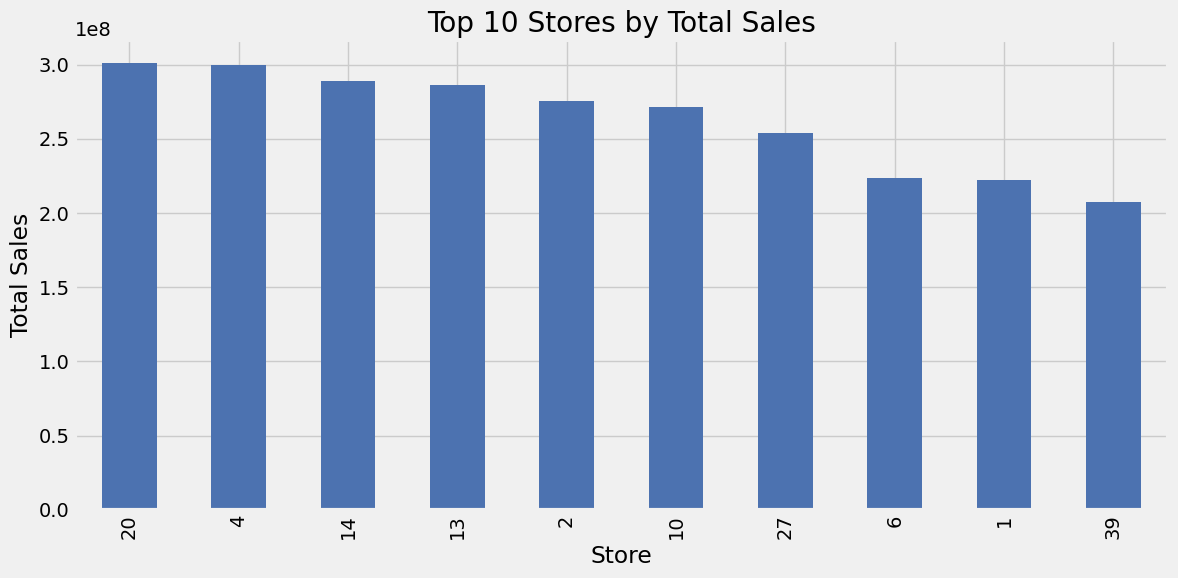

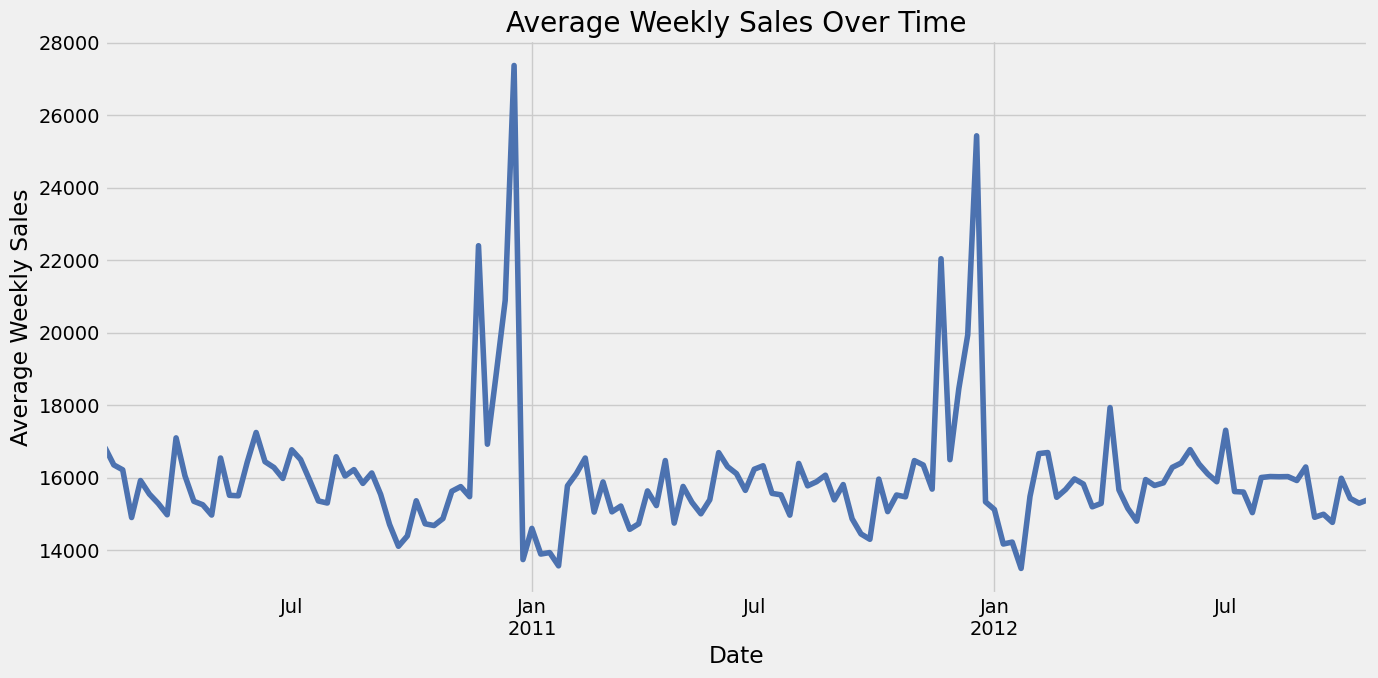

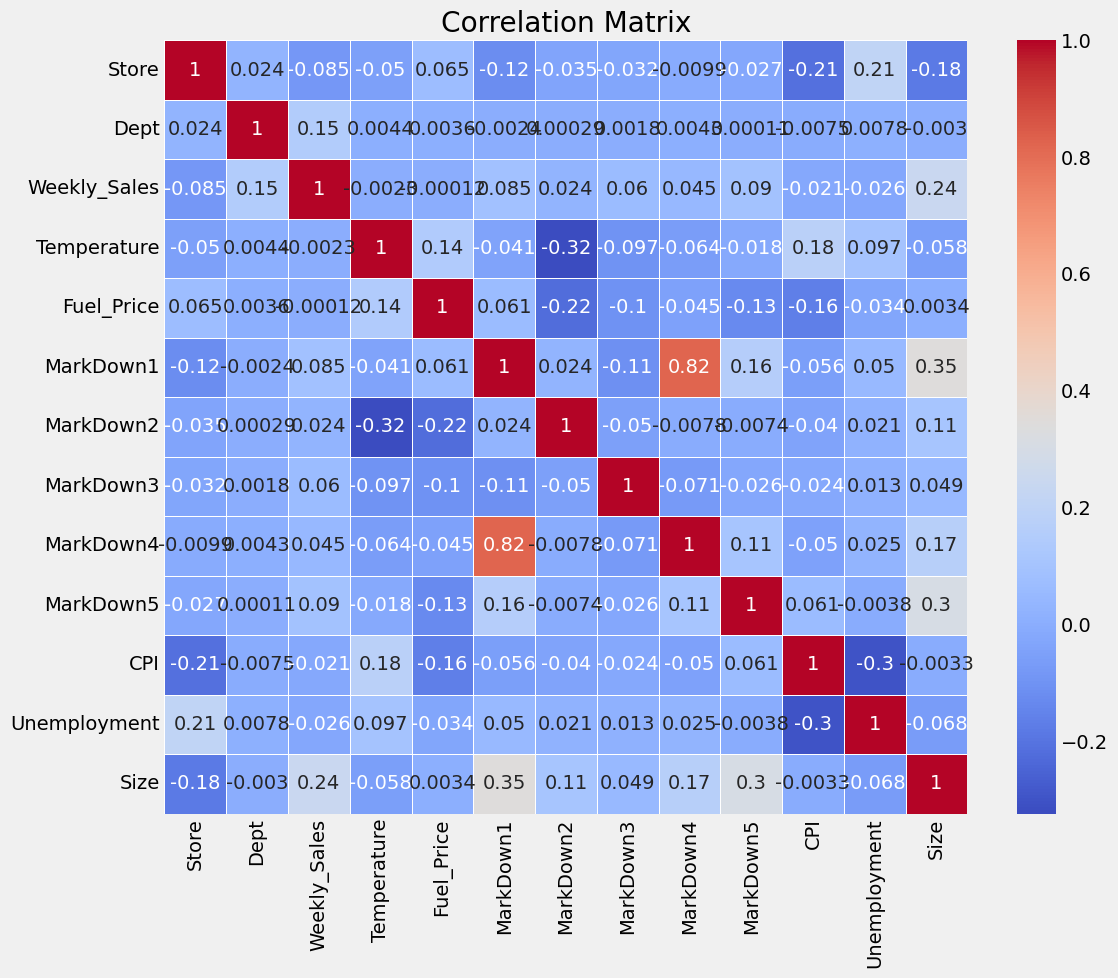

In [22]:
time_series = exploratory_analysis(data)

In [23]:
data_engineered = feature_engineering(data)


=== Feature Engineering ===
Feature engineering completed. New shape: (421570, 33)


In [24]:
X_train_scaled, X_test_scaled, y_train, y_test, X_train_raw, X_test_raw, train_data, test_data = prepare_train_test_data(data_engineered)


=== Preparing Training and Test Data ===
Data shape after removing NaN values: (97056, 33)
Train data shape: (78694, 34)
Test data shape: (18362, 34)


In [26]:
rf_model, rf_preds, rf_rmse, rf_mae, rf_mape = train_random_forest(X_train_scaled, y_train, X_test_scaled, y_test)


=== Training Random Forest Model ===
Random Forest RMSE: 2336.37
Random Forest MAE: 1095.19
Random Forest MAPE: inf%

Top 10 Important Features:
   Feature  Importance
19     X19    0.932032
20     X20    0.022716
18     X18    0.008658
7       X7    0.007704
5       X5    0.006203
17     X17    0.005559
8       X8    0.003800
14     X14    0.003216
6       X6    0.002663
1       X1    0.001602


In [27]:
xgb_model, xgb_preds, xgb_rmse, xgb_mae, xgb_mape = train_xgboost(X_train_scaled, y_train, X_test_scaled, y_test)


=== Training XGBoost Model ===
XGBoost RMSE: 2827.42
XGBoost MAE: 1301.83
XGBoost MAPE: inf%



=== Training SARIMA Model for Store 1, Department 1 ===
SARIMA RMSE: 3954.76
SARIMA MAE: 2443.53
SARIMA MAPE: nan%


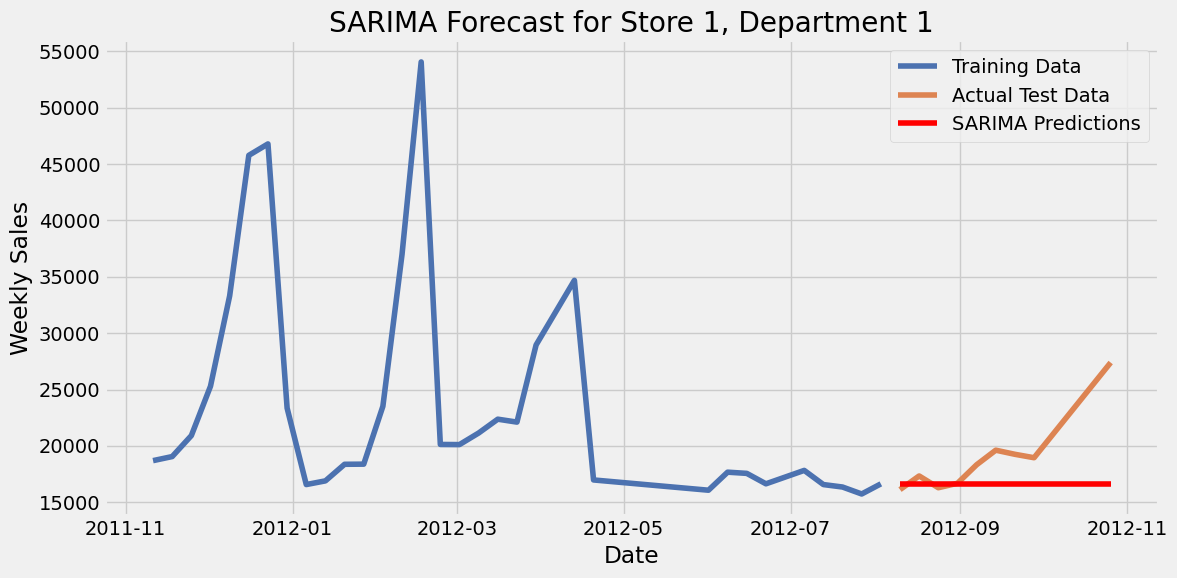

In [28]:
sarima_model, sarima_preds, sarima_rmse, sarima_mae, sarima_mape = train_sarima(train_data, test_data, store=1, dept=1)


=== Model Comparison ===
           Model         RMSE          MAE  MAPE (%)
0  Random Forest  2336.371708  1095.189840       inf
1        XGBoost  2827.422022  1301.833758       inf
2         SARIMA  3954.764623  2443.531111       NaN

Best model based on RMSE: Random Forest


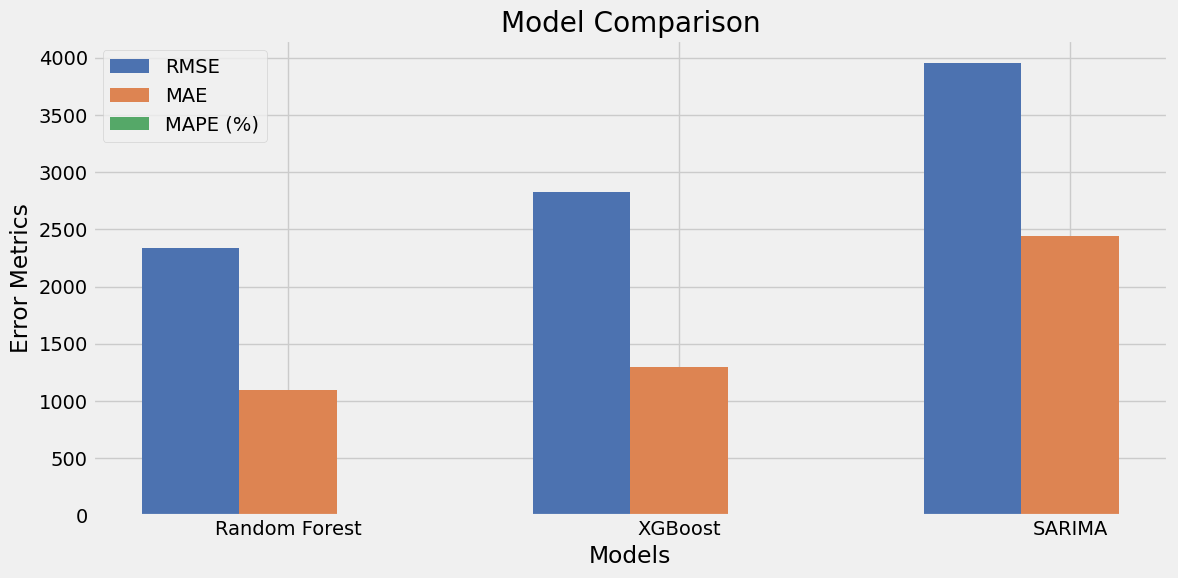

In [31]:
if sarima_rmse is not None:
    compare_models((rf_rmse, rf_mae, rf_mape),
                 (xgb_rmse, xgb_mae, xgb_mape),
                 (sarima_rmse, sarima_mae, sarima_mape))
else:
    compare_models((rf_rmse, rf_mae, rf_mape),
                 (xgb_rmse, xgb_mae, xgb_mape))

In [32]:
scaler = StandardScaler()
scaler.fit(X_train_raw)
save_models(rf_model, xgb_model, scaler)


=== Saving Models for Deployment ===
Models saved successfully.
